# Deep Dive Exploratory Data Analysis (EDA)
Welcome to the comprehensive EDA for the **Movies** dataset. This notebook follows a structured, beginner-friendly approach to uncovering insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('../datasets/movies.csv')

## 1. DATASET OVERVIEW
Here we take our first look at the dataset to understand its shape and structure.

In [2]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")
print("Column Data Types:")
display(df.dtypes)

# Briefly preview the first few rows
display(df.head())

Number of Rows: 7668
Number of Columns: 15

Column Data Types:


name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


**Interpretation**: 
- **Numerical Features**: `year`, `score`, `votes`, `budget`, `gross`, `runtime`.
- **Categorical Features**: `name`, `rating`, `genre`, `released`, `director`, `writer`, `star`, `country`, `company`.
- The columns represent attributes of a movie, its box office performance (`gross`, `budget`), and its critical reception (`score`, `votes`).

## 2. DATA QUALITY CHECK
Let's identify missing values, duplicates, and general inconsistencies.

In [3]:
print("\n--- MISSING VALUES ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

print(f"\nDuplicate Rows: {df.duplicated().sum()}")


--- MISSING VALUES ---


,Missing Count,Percentage (%)
budget,2171,28.312467
gross,189,2.464789
rating,77,1.004173
company,17,0.221701
runtime,4,0.052165
score,3,0.039124
votes,3,0.039124
writer,3,0.039124
country,3,0.039124
released,2,0.026082



Duplicate Rows: 0


**Interpretation**:
- `budget` and `gross` have a notable amount of missing values. We may need to impute or drop them depending on our analysis goals.
- Zero or very few duplicate rows indicate a clean collection of unique movie titles.

## 3. UNIVARIATE ANALYSIS
Exploring individual variables separately.


--- NUMERICAL SUMMARY ---


,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


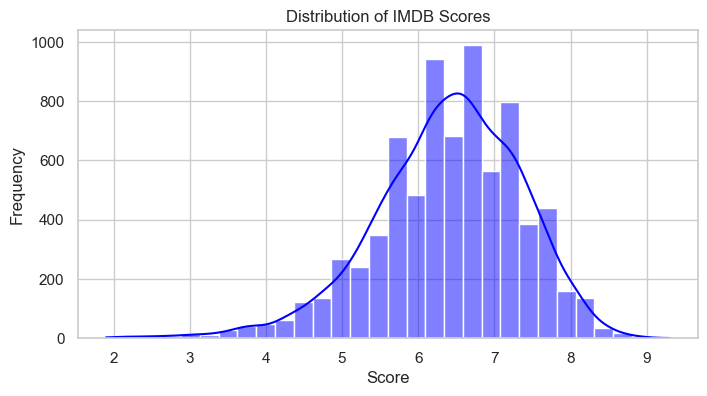


--- CATEGORICAL SUMMARY (Genre) ---


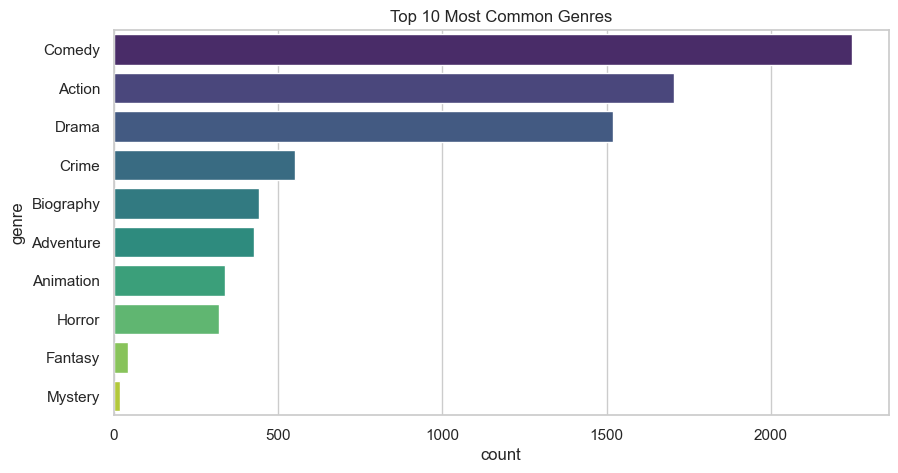

In [4]:
print("\n--- NUMERICAL SUMMARY ---")
display(df.describe())

# Histogram of 'score'
plt.figure(figsize=(8, 4))
sns.histplot(df['score'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of IMDB Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

print("\n--- CATEGORICAL SUMMARY (Genre) ---")
plt.figure(figsize=(10, 5))
sns.countplot(y=df['genre'], order=df['genre'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Most Common Genres')
plt.show()

**Interpretation**:
- Scores seem to follow a normal distribution roughly centered around 6 to 7.
- Comedy, Action, and Drama are typically the most frequent genres.

## 4. BIVARIATE ANALYSIS
Seeing how variables interact with one another, especially with revenue/gross.


--- CORRELATION MATRIX ---


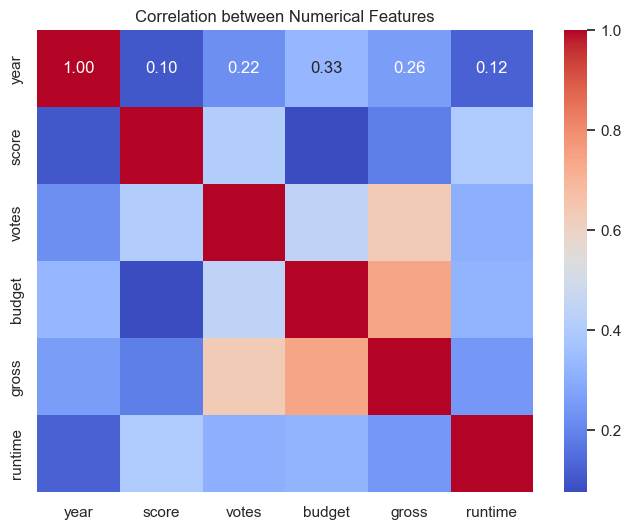

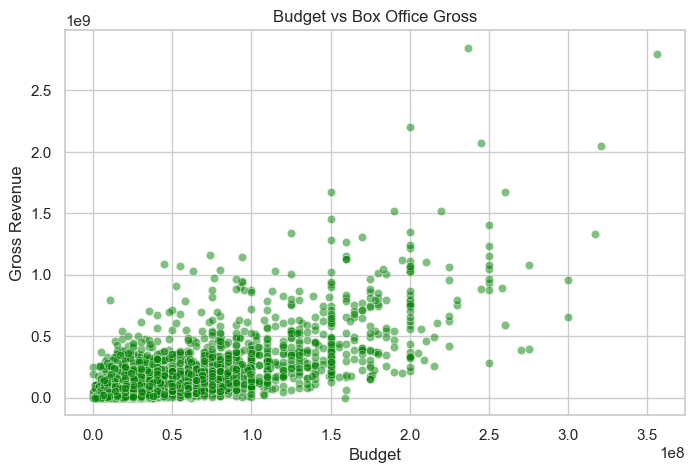

In [5]:
print("\n--- CORRELATION MATRIX ---")
num_cols = df.select_dtypes(include=[np.number])
corr_matrix = num_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Numerical Features")
plt.show()

# Scatter plot for Budget vs Gross
plt.figure(figsize=(8, 5))
sns.scatterplot(x='budget', y='gross', data=df, alpha=0.5, color='green')
plt.title('Budget vs Box Office Gross')
plt.xlabel('Budget')
plt.ylabel('Gross Revenue')
plt.show()

**Interpretation**:
- `budget` and `gross` typically show a strong positive correlation (higher budget often translates to higher revenue).
- `votes` and `gross` also show correlation, implying popular, heavily-reviewed movies make more money.

## 5. MULTIVARIATE ANALYSIS
Let's look at how gross breaks down by genre and budget.

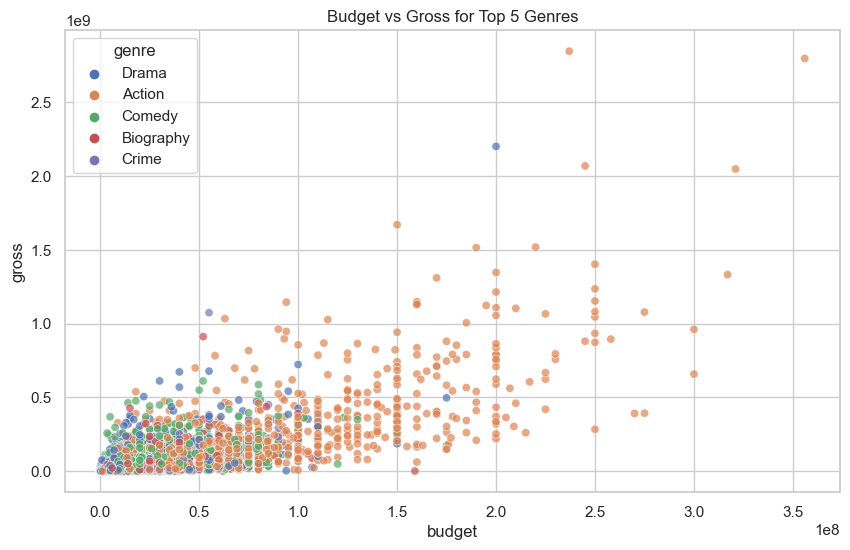

In [6]:
top_genres = df['genre'].value_counts().index[:5]
df_top_genres = df[df['genre'].isin(top_genres)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='gross', hue='genre', data=df_top_genres, alpha=0.7)
plt.title('Budget vs Gross for Top 5 Genres')
plt.show()

**Interpretation**:
- Action and Animation movies typically lie on the higher end of both `budget` and `gross`.
- Comedies and Dramas can achieve high gross with lower budgets.

## 6. TARGET VARIABLE ANALYSIS
Assuming `gross` (box office revenue) as our primary target.

c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


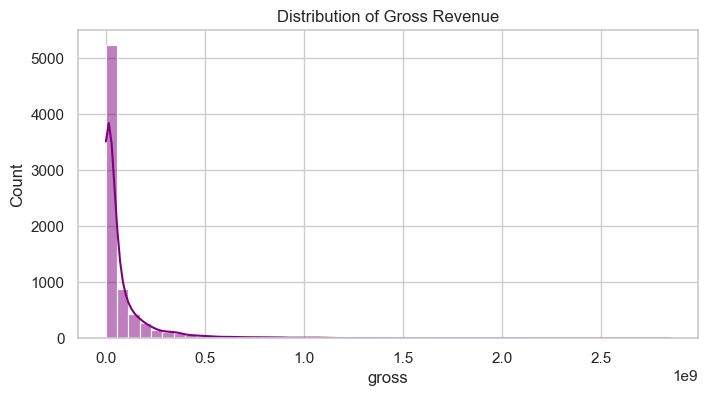

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df['gross'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Gross Revenue')
plt.show()

**Interpretation**:
- The distribution is heavily **right-skewed**, meaning a vast majority of movies make moderate amounts, while a few blockbusters make exceptionally large amounts.

## 7. FEATURE ENGINEERING SUGGESTIONS
- **Profit**: `df["profit"] = df["gross"] - df["budget"]`
- **Return on Investment (ROI)**: `df["roi"] = (df["gross"] - df["budget"]) / df["budget"]`
- **Release Month/Year extracted** from the `released` column to track seasonal trends.
- Deal with missing values in `budget` by either imputing the median for the genre, or dropping rows if we strictly need budget data.

## 8. KEY INSIGHTS
1. **Budget Drives Revenue**: There is a substantial positive correlation between how much a movie costs and how much it earns.
2. **Popularity Matters**: `votes` strongly correlates with `gross`, indicating well-known movies earn more.
3. **Score is Independent of Financial Success**: Strangely, `score` has a very low correlation with `gross` and `budget`, meaning great reviews do not guarantee a blockbuster, and blockbusters are not necessarily high-rated by critics.
4. **Missing Data**: A significant chunk of `budget` data is missing and requires careful handling.
5. **High Variance**: The data has massive outliers in revenue, characterized by a few major hits pulling up the averages.

## 9. MODELING RECOMMENDATIONS
- **Problem Type**: Regression (predicting continuous `gross` revenue).
- **Algorithms**: 
  - Linear Regression (Baseline)
  - Random Forest Regressor or XG Boost (To handle non-linear relationships and outliers from blockbusters).
- **Key Features to Use**: `budget`, `votes`, `runtime`, `genre`, `director`, `company`.

## 10. VISUALIZATION SUGGESTIONS
- **Scatter plots** for `budget` vs `gross` to clearly illustrate the linear relationship.
- **Box plots** of `gross` grouped by `genre` or `rating` to see the spread and identify which categories are the most lucrative.
- **Time series line plot** of year over year total gross to see industry growth over time.